In [77]:
import pandas as pd


In [78]:
df = pd.read_csv("../data preparation 1/sales_prepared_1.csv")
df


,Date,Revenue,COGS,doy,is_promo,year,month,quarter,season
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7,3,Summer
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7,3,Summer
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7,3,Summer
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7,3,Summer
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7,3,Summer
...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12,4,Winter
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12,4,Winter
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12,4,Winter
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12,4,Winter


In [79]:
df['Date'] = pd.to_datetime(df['Date'])


In [80]:
import numpy as np
df['days_in_year'] = df['Date'].dt.is_leap_year.apply(lambda x: 366 if x else 365)

df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / df['days_in_year'])
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / df['days_in_year'])


In [81]:
df


,Date,Revenue,COGS,doy,is_promo,year,month,quarter,season,days_in_year,doy_sin,doy_cos
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7,3,Summer,366,-5.147875e-02,-0.998674
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7,3,Summer,366,-6.861474e-02,-0.997643
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7,3,Summer,366,-8.573050e-02,-0.996318
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7,3,Summer,366,-1.028210e-01,-0.994700
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7,3,Summer,366,-1.198812e-01,-0.992788
...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12,4,Winter,365,-6.880243e-02,0.997630
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12,4,Winter,365,-5.161967e-02,0.998667
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12,4,Winter,365,-3.442161e-02,0.999407
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12,4,Winter,365,-1.721336e-02,0.999852


In [82]:
df['promo_past_14'] = df['is_promo'].rolling(14, min_periods=1).sum()
df['promo_past_28'] = df['is_promo'].rolling(28, min_periods=1).sum()
df['promo_past_42'] = df['is_promo'].rolling(42, min_periods=1).sum()
df


,Date,Revenue,COGS,doy,is_promo,year,month,quarter,season,days_in_year,doy_sin,doy_cos,promo_past_14,promo_past_28,promo_past_42
0,2012-07-04,5123547.94,3982991.19,186,1,2012,7,3,Summer,366,-5.147875e-02,-0.998674,1.0,1.0,1.0
1,2012-07-05,2751773.45,2150580.23,187,1,2012,7,3,Summer,366,-6.861474e-02,-0.997643,2.0,2.0,2.0
2,2012-07-06,3054029.42,2517632.84,188,1,2012,7,3,Summer,366,-8.573050e-02,-0.996318,3.0,3.0,3.0
3,2012-07-07,2667930.94,2108246.62,189,1,2012,7,3,Summer,366,-1.028210e-01,-0.994700,4.0,4.0,4.0
4,2012-07-08,2360851.90,1808622.79,190,1,2012,7,3,Summer,366,-1.198812e-01,-0.992788,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,361,1,2022,12,4,Winter,365,-6.880243e-02,0.997630,14.0,28.0,40.0
3829,2022-12-28,3448729.20,3513621.00,362,1,2022,12,4,Winter,365,-5.161967e-02,0.998667,14.0,28.0,41.0
3830,2022-12-29,3083944.33,3170787.10,363,1,2022,12,4,Winter,365,-3.442161e-02,0.999407,14.0,28.0,42.0
3831,2022-12-30,2884668.76,3022292.15,364,1,2022,12,4,Winter,365,-1.721336e-02,0.999852,14.0,28.0,42.0


In [83]:
df.to_csv('../data preparation 2/sales_prepared_2.csv', index=False)


In [84]:
X = df.drop('Date', axis=1)
X


,Revenue,COGS,doy,is_promo,year,month,quarter,season,days_in_year,doy_sin,doy_cos,promo_past_14,promo_past_28,promo_past_42
0,5123547.94,3982991.19,186,1,2012,7,3,Summer,366,-5.147875e-02,-0.998674,1.0,1.0,1.0
1,2751773.45,2150580.23,187,1,2012,7,3,Summer,366,-6.861474e-02,-0.997643,2.0,2.0,2.0
2,3054029.42,2517632.84,188,1,2012,7,3,Summer,366,-8.573050e-02,-0.996318,3.0,3.0,3.0
3,2667930.94,2108246.62,189,1,2012,7,3,Summer,366,-1.028210e-01,-0.994700,4.0,4.0,4.0
4,2360851.90,1808622.79,190,1,2012,7,3,Summer,366,-1.198812e-01,-0.992788,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2100553.66,2184872.24,361,1,2022,12,4,Winter,365,-6.880243e-02,0.997630,14.0,28.0,40.0
3829,3448729.20,3513621.00,362,1,2022,12,4,Winter,365,-5.161967e-02,0.998667,14.0,28.0,41.0
3830,3083944.33,3170787.10,363,1,2022,12,4,Winter,365,-3.442161e-02,0.999407,14.0,28.0,42.0
3831,2884668.76,3022292.15,364,1,2022,12,4,Winter,365,-1.721336e-02,0.999852,14.0,28.0,42.0


# Test model

In [85]:
y_rev = df['Revenue']
y_cogs = df['COGS']


In [86]:
X.drop(columns=['Revenue','COGS'], inplace=True)


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# import LightGBM
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error


In [88]:
X_rev_train, X_rev_test, y_rev_train, y_rev_test = train_test_split(X, y_rev, test_size=0.2, random_state=42)
X_cogs_train, X_cogs_test, y_cogs_train, y_cogs_test = train_test_split(X, y_cogs, test_size=0.2, random_state=42)


In [89]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_rev_train['season'] = le.fit_transform(X_rev_train['season'])
X_rev_test['season'] = le.transform(X_rev_test['season'])


In [90]:
mapping = {label: i for i, label in enumerate(le.classes_)}
mapping


{'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

In [91]:
model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_rev_train, y_rev_train)
y_rev_pred = model.predict(X_rev_test)
mae_rev = mean_absolute_error(y_rev_test, y_rev_pred)
print(f"MAE for Revenue: {mae_rev:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 3066, number of used features: 12
[LightGBM] [Info] Start training from score 4278176.236291
MAE for Revenue: 745107.56


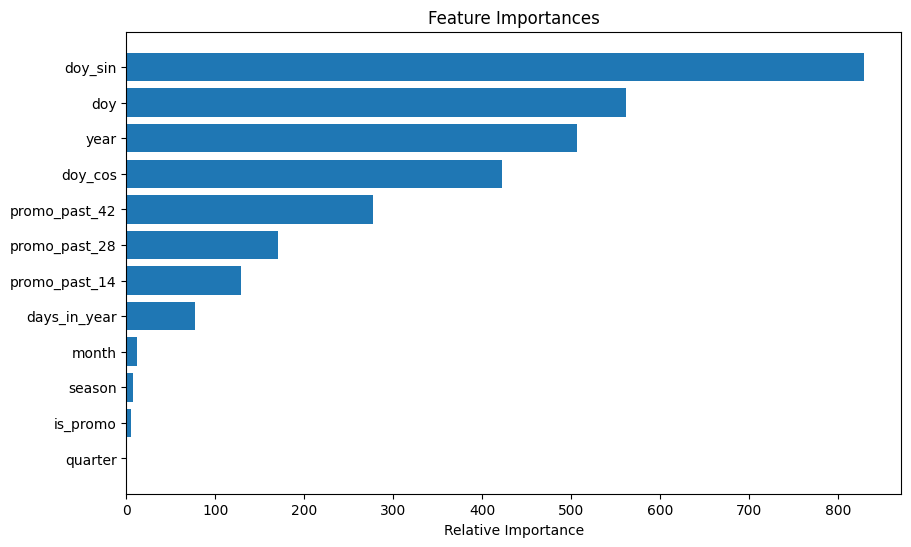

In [92]:
# Show feature importance
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = X_rev_train.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [93]:
import joblib
joblib.dump(model, 'rev_model.pkl')


['rev_model.pkl']

In [94]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_cogs_train['season'] = le.fit_transform(X_cogs_train['season'])
X_cogs_test['season'] = le.transform(X_cogs_test['season'])


In [95]:
mapping = {label: i for i, label in enumerate(le.classes_)}
mapping


{'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

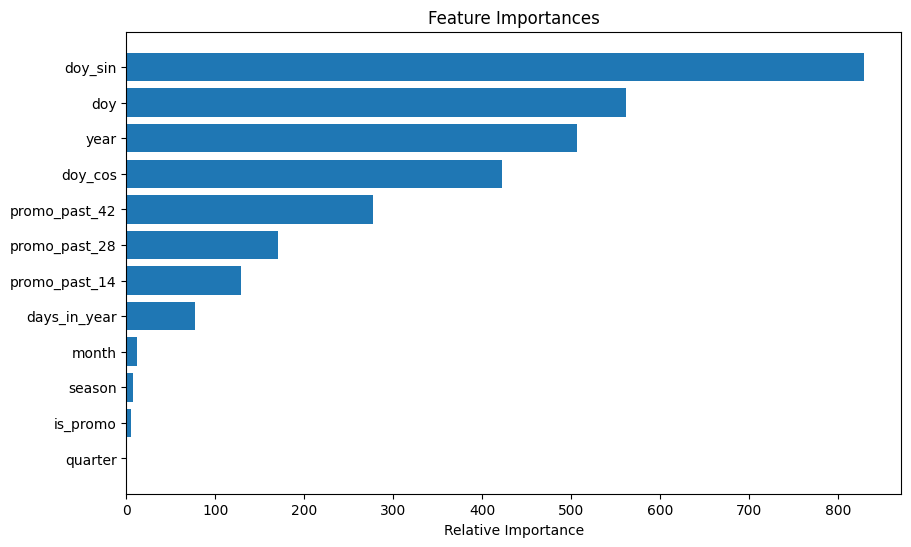

In [96]:
# Show feature importance
import matplotlib.pyplot as plt
importances = model.feature_importances_
feature_names = X_cogs_train.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [97]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_cogs_train, y_cogs_train)
y_cogs_pred = model.predict(X_cogs_test)
mae_cogs = mean_absolute_error(y_cogs_test, y_cogs_pred)
print(f"MAE for COGS: {mae_cogs:.2f}")


MAE for COGS: 584439.58


In [98]:
import joblib
joblib.dump(model, 'cogs_model.pkl')


['cogs_model.pkl']